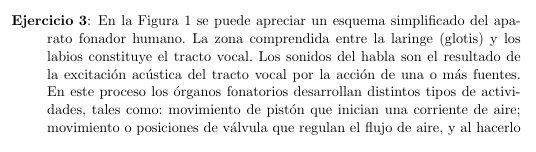

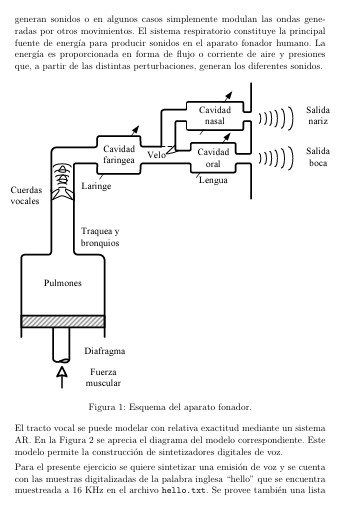

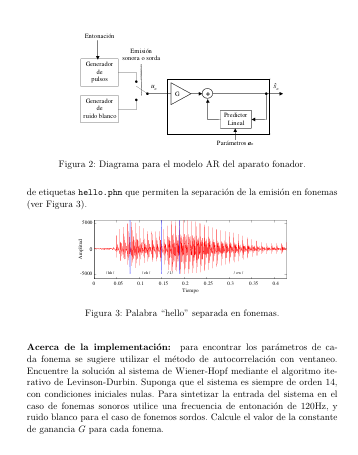


In [94]:
import numpy as np
import matplotlib.pyplot as plt
import csv

In [95]:
def cargar_dataset(nombre_archivo):
    dataset = []
    i = 0
    with open(nombre_archivo, newline='') as csvfile:
      reader = csv.reader(csvfile)
      for row in reader:
        if row:
            dataset.append(row[0])
    dataset = np.array(dataset)
    dataset = dataset[:].astype(float)
    return dataset

salida = cargar_dataset("PDS_TP1_signals/hello.txt")
salida /= max(salida)

#idx = np.arange(0, salida.shape[0], 5)
#salida = salida[idx]
N = len(salida)
#salida -= np.mean(salida)
print(salida.shape)

phonem = [1270,2379,3046, 5100]
# H E LL O-U
PHONEMS = [salida[800:1270], salida[1270:2379], salida[2379:3046], salida[3046:5100], salida[5100:]]

(7323,)


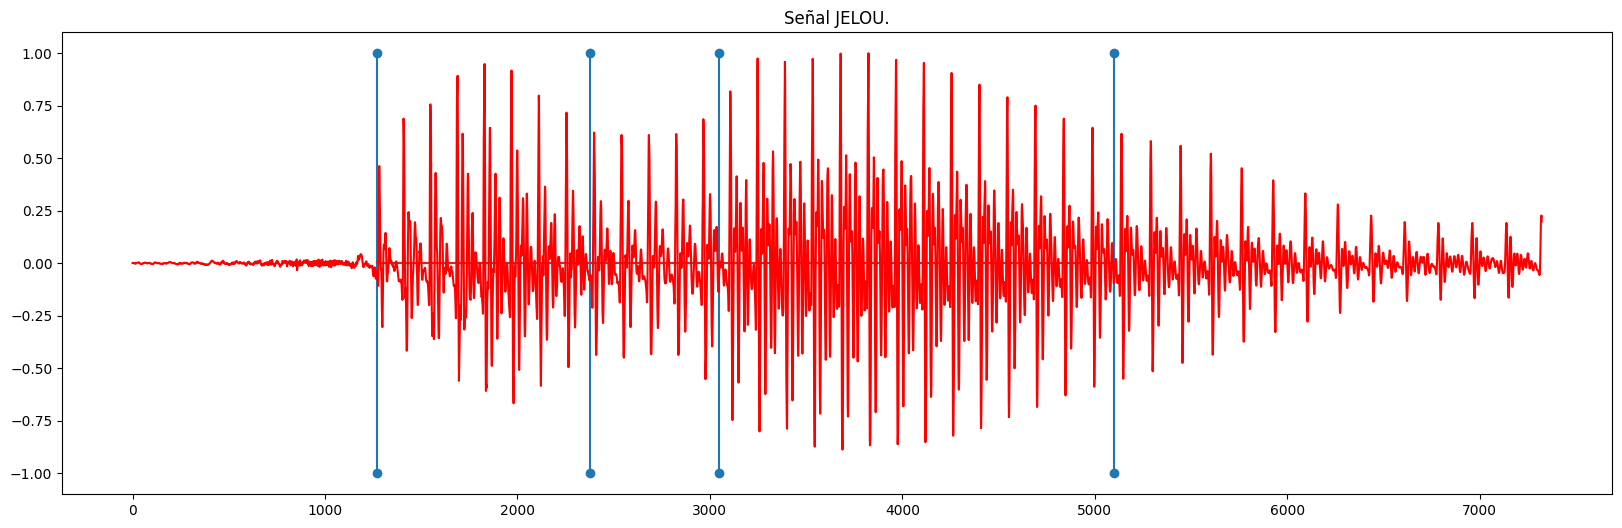

In [96]:
dom = np.arange(0,len(salida), 1)
plt.figure(figsize=(20,6))
plt.title("Señal JELOU.")
plt.stem(phonem, np.ones_like(phonem))
plt.stem(phonem, -np.ones_like(phonem))
plt.plot(dom, salida, color='red')
plt.show()

In [97]:
def obtener_R(orden, salida):
    R = []
    for p in range(orden+1):
        r_s_i = 0
        for n in range(len(salida)):
            r_s_i += salida[n - p] * salida[n]
        R.append(r_s_i/len(salida))
    R = np.array(R)
    return R

def obtener_matriz_coeficientes(orden, R):
    p = orden
    A = np.zeros((p,p))
    E = [R[0]]

    for i in range(0, p):
      elemento = 0
      for j in range(0, i):
          elemento += A[j,i-1] * R[i-j]
      k_i = -1/E[-1] * (R[i+1] + elemento)
      A[i,i] = k_i
      for j in range(0, i):
          A[j,i] = A[j,i-1] + k_i*A[i-j-1, i-1]
      E.append(E[-1]*(1 - k_i**2))

    #A = -A
    return A, E

#A = np.zeros((orden,orden))
#E = [R[0]]
orden = 14
Rs = []
As = []
Es = []
for i in range(len(PHONEMS)):
    salida_i = PHONEMS[i]
    R = obtener_R(orden, salida_i)
    A, E = obtener_matriz_coeficientes(orden, R)
    Rs.append(R)
    As.append(A)
    Es.append(E)
N = len(salida)

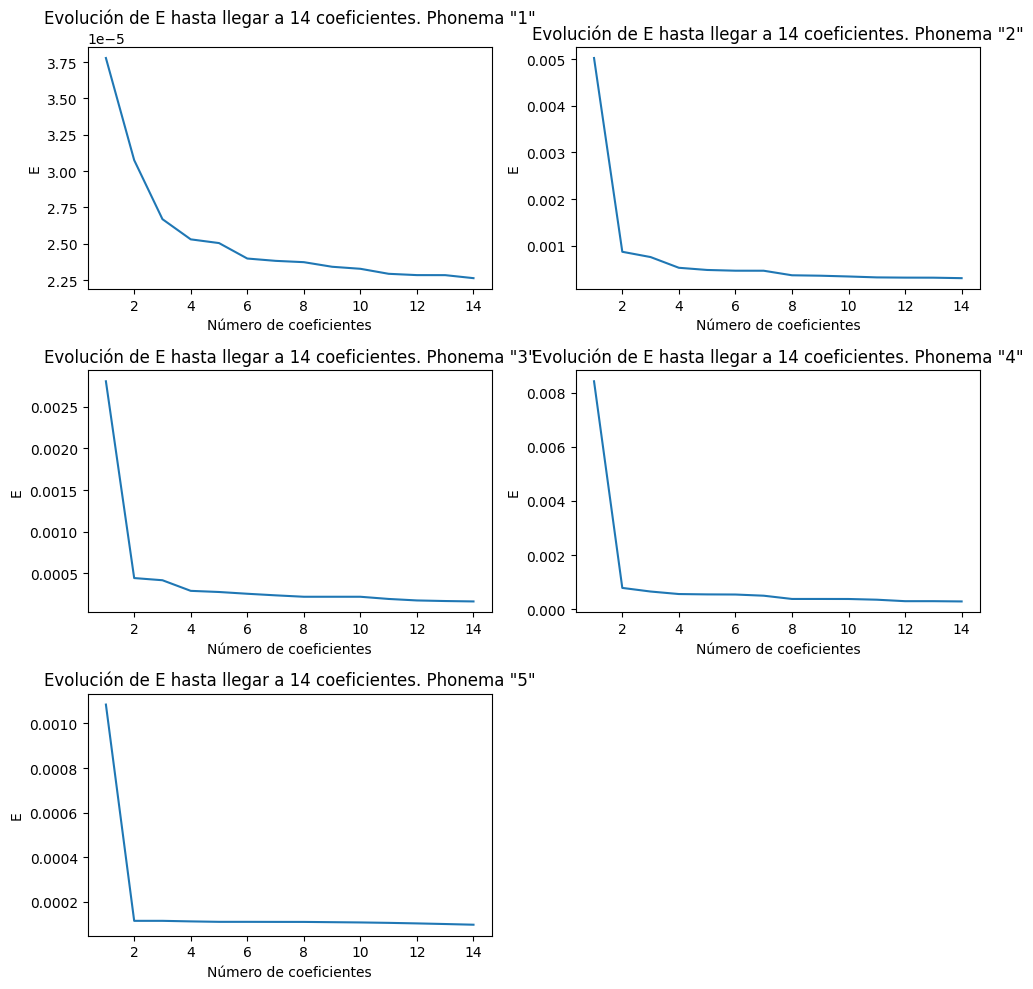

In [98]:
plt.figure(figsize=(10,10))

for i in range(len(Es)):
    plt.subplot(3, 2, i+1)
    dom = np.arange(1,len(Es[i]), 1)
    plt.title(f'Evolución de E hasta llegar a {orden} coeficientes. Phonema "{i+1}"')
    plt.xlabel("Número de coeficientes")
    plt.ylabel("E")
    plt.tight_layout()
    plt.plot(dom, Es[i][1:])
plt.show()

In [99]:
f_entonacion = 120
f_muestreo = 16000
T = int(f_muestreo/f_entonacion) # Numero de muestras entre pulsos unitarios

As_definitivos = []
for i in range(len(As)):
    As_definitivos.append(As[i][13])

Es_definitivos = []
for i in range(len(Es)):
    Es_definitivos.append(Es[i][13])

As_definitivos = np.array(As_definitivos)
Es_definitivos = np.array(Es_definitivos)
print(As_definitivos.shape)

Ganancias = np.sqrt(Es_definitivos)

salidas_reconstruidas = []
for phonema in range(As_definitivos.shape[0]):
    if phonema == 0:
        # RUIDO BLANCO
        entrada = np.random.rand()*2 - 1
        salida_rec = np.zeros(len(PHONEMS[0]))
        salida_rec[0] = entrada
        for j in range(len(salida_rec)):
            for n in range(As_definitivos.shape[1]):
                if j-n-1 >=0:
                    salida_rec[j] += As_definitivos[0,n]*salida_rec[j-n-1] 
    else:
        # PULSO 120 Hz
        entrada = np.zeros(len(PHONEMS[phonema]))
        for j in range(len(entrada)):
            if j % T == 0:
                entrada[j] = 1
    
        salida_rec = np.zeros(len(PHONEMS[phonema]))
        salida_rec = entrada
        for j in range(len(salida_rec)):
            for n in range(As_definitivos.shape[1]):
                if j-n-1 >=0:
                    salida_rec[j] += As_definitivos[0,n]*salida_rec[j-n-1] 
    salidas_reconstruidas.append(salida_rec)

salidas_reconstruidas = [x for sublist in salidas_reconstruidas for x in sublist]
salidas_reconstruidas = np.array(salidas_reconstruidas)

np.savetxt("PDS_TP1_signals/hello_reconstruido.txt", salidas_reconstruidas)
 

(5, 14)


In [100]:
from scipy.io.wavfile import write

# cargar los datos (una columna de números)
data = np.loadtxt("PDS_TP1_signals/hello.txt")

# normalizar si hace falta (ejemplo para float)
data = data / np.max(np.abs(data))

# convertir a 16 bits
data_int16 = np.int16(data * 32767)

# guardar como WAV (ej: 44100 Hz)
write("PDS_TP1_signals/audio_hello.wav", 16000, data_int16)


In [101]:
# cargar los datos (una columna de números)
data = np.loadtxt("PDS_TP1_signals/hello_reconstruido.txt")

# normalizar si hace falta (ejemplo para float)
data = data / np.max(np.abs(data))

# convertir a 16 bits
data_int16 = np.int16(data * 32767)

# guardar como WAV (ej: 44100 Hz)
write("PDS_TP1_signals/audio_hello_reconstruido.wav", 16000, data_int16)
